# Swarm Plot

A swarm plot draws every observation as its own point, grouped by category and spread sideways so no point hides another. Where a box plot summarizes a sample, a swarm shows it whole, which matters when the sample is small or when single points are the story: an outlier with a name, a cluster, a gap. This guide shows how to create swarm plots with the [datachart.charts.SwarmPlot](../../../references/charts/swarmplot/#datachart.charts.SwarmPlot) function, starting with the basics and building up to worked examples on real data.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-swarm-plot), which maps common tasks to the parameter or style attribute that does the job.

In [1]:
from datachart.charts import SwarmPlot

## Basics

The examples in this guide share one small dataset: the 47 presidencies of the United States in their official numbering (Grover Cleveland and Donald Trump each count twice), with the age of each president on the day he took office. The ages are computed from the birth and inauguration dates published in the White House presidential biographies. The data lives in a hidden cell. `PRESIDENCIES` holds one row per presidency (name, party, birth date, first day and last day in office), and `inauguration_ages` holds one data point per presidency, labeled with its era: the presidencies that began in 1789–1897, in 1901–1993, and in 2001–2025. With 47 points, every point is a person, and the extremes have names: the youngest president, Theodore Roosevelt, and the two oldest, both sworn in during the last era.

In [2]:
from datetime import date

# the US presidencies: (name, party, born, took office, left office)
PRESIDENCIES = [
    ("George Washington", "Unaffiliated", date(1732, 2, 22), date(1789, 4, 30), date(1797, 3, 4)),
    ("John Adams", "Federalist", date(1735, 10, 30), date(1797, 3, 4), date(1801, 3, 4)),
    ("Thomas Jefferson", "Democratic-Republican", date(1743, 4, 13), date(1801, 3, 4), date(1809, 3, 4)),
    ("James Madison", "Democratic-Republican", date(1751, 3, 16), date(1809, 3, 4), date(1817, 3, 4)),
    ("James Monroe", "Democratic-Republican", date(1758, 4, 28), date(1817, 3, 4), date(1825, 3, 4)),
    ("John Quincy Adams", "Democratic-Republican", date(1767, 7, 11), date(1825, 3, 4), date(1829, 3, 4)),
    ("Andrew Jackson", "Democratic", date(1767, 3, 15), date(1829, 3, 4), date(1837, 3, 4)),
    ("Martin Van Buren", "Democratic", date(1782, 12, 5), date(1837, 3, 4), date(1841, 3, 4)),
    ("William Henry Harrison", "Whig", date(1773, 2, 9), date(1841, 3, 4), date(1841, 4, 4)),
    ("John Tyler", "Whig", date(1790, 3, 29), date(1841, 4, 4), date(1845, 3, 4)),
    ("James K. Polk", "Democratic", date(1795, 11, 2), date(1845, 3, 4), date(1849, 3, 4)),
    ("Zachary Taylor", "Whig", date(1784, 11, 24), date(1849, 3, 5), date(1850, 7, 9)),
    ("Millard Fillmore", "Whig", date(1800, 1, 7), date(1850, 7, 9), date(1853, 3, 4)),
    ("Franklin Pierce", "Democratic", date(1804, 11, 23), date(1853, 3, 4), date(1857, 3, 4)),
    ("James Buchanan", "Democratic", date(1791, 4, 23), date(1857, 3, 4), date(1861, 3, 4)),
    ("Abraham Lincoln", "Republican", date(1809, 2, 12), date(1861, 3, 4), date(1865, 4, 15)),
    ("Andrew Johnson", "National Union", date(1808, 12, 29), date(1865, 4, 15), date(1869, 3, 4)),
    ("Ulysses S. Grant", "Republican", date(1822, 4, 27), date(1869, 3, 4), date(1877, 3, 4)),
    ("Rutherford B. Hayes", "Republican", date(1822, 10, 4), date(1877, 3, 4), date(1881, 3, 4)),
    ("James A. Garfield", "Republican", date(1831, 11, 19), date(1881, 3, 4), date(1881, 9, 19)),
    ("Chester A. Arthur", "Republican", date(1829, 10, 5), date(1881, 9, 19), date(1885, 3, 4)),
    ("Grover Cleveland", "Democratic", date(1837, 3, 18), date(1885, 3, 4), date(1889, 3, 4)),
    ("Benjamin Harrison", "Republican", date(1833, 8, 20), date(1889, 3, 4), date(1893, 3, 4)),
    ("Grover Cleveland", "Democratic", date(1837, 3, 18), date(1893, 3, 4), date(1897, 3, 4)),
    ("William McKinley", "Republican", date(1843, 1, 29), date(1897, 3, 4), date(1901, 9, 14)),
    ("Theodore Roosevelt", "Republican", date(1858, 10, 27), date(1901, 9, 14), date(1909, 3, 4)),
    ("William Howard Taft", "Republican", date(1857, 9, 15), date(1909, 3, 4), date(1913, 3, 4)),
    ("Woodrow Wilson", "Democratic", date(1856, 12, 28), date(1913, 3, 4), date(1921, 3, 4)),
    ("Warren G. Harding", "Republican", date(1865, 11, 2), date(1921, 3, 4), date(1923, 8, 2)),
    ("Calvin Coolidge", "Republican", date(1872, 7, 4), date(1923, 8, 2), date(1929, 3, 4)),
    ("Herbert Hoover", "Republican", date(1874, 8, 10), date(1929, 3, 4), date(1933, 3, 4)),
    ("Franklin D. Roosevelt", "Democratic", date(1882, 1, 30), date(1933, 3, 4), date(1945, 4, 12)),
    ("Harry S. Truman", "Democratic", date(1884, 5, 8), date(1945, 4, 12), date(1953, 1, 20)),
    ("Dwight D. Eisenhower", "Republican", date(1890, 10, 14), date(1953, 1, 20), date(1961, 1, 20)),
    ("John F. Kennedy", "Democratic", date(1917, 5, 29), date(1961, 1, 20), date(1963, 11, 22)),
    ("Lyndon B. Johnson", "Democratic", date(1908, 8, 27), date(1963, 11, 22), date(1969, 1, 20)),
    ("Richard Nixon", "Republican", date(1913, 1, 9), date(1969, 1, 20), date(1974, 8, 9)),
    ("Gerald Ford", "Republican", date(1913, 7, 14), date(1974, 8, 9), date(1977, 1, 20)),
    ("Jimmy Carter", "Democratic", date(1924, 10, 1), date(1977, 1, 20), date(1981, 1, 20)),
    ("Ronald Reagan", "Republican", date(1911, 2, 6), date(1981, 1, 20), date(1989, 1, 20)),
    ("George H. W. Bush", "Republican", date(1924, 6, 12), date(1989, 1, 20), date(1993, 1, 20)),
    ("Bill Clinton", "Democratic", date(1946, 8, 19), date(1993, 1, 20), date(2001, 1, 20)),
    ("George W. Bush", "Republican", date(1946, 7, 6), date(2001, 1, 20), date(2009, 1, 20)),
    ("Barack Obama", "Democratic", date(1961, 8, 4), date(2009, 1, 20), date(2017, 1, 20)),
    ("Donald Trump", "Republican", date(1946, 6, 14), date(2017, 1, 20), date(2021, 1, 20)),
    ("Joe Biden", "Democratic", date(1942, 11, 20), date(2021, 1, 20), date(2025, 1, 20)),
    ("Donald Trump", "Republican", date(1946, 6, 14), date(2025, 1, 20), None),  # in office
]
ERAS = ["1789–1897", "1901–1993", "2001–2025"]


def era(took_office):
    return ERAS[0] if took_office.year < 1901 else ERAS[1] if took_office.year < 2001 else ERAS[2]


def age_on(born, day):
    return day.year - born.year - ((day.month, day.day) < (born.month, born.day))


inauguration_ages = [
    {"label": era(took), "value": age_on(born, took)}
    for _, _, born, took, _ in PRESIDENCIES
]

Each data point is a dictionary with a `label` (the group) and a `value`. The points that share a `label` form one swarm, so three eras give three swarms:

In [3]:
inauguration_ages[:3]

[{'label': '1789–1897', 'value': 57},
 {'label': '1789–1897', 'value': 61},
 {'label': '1789–1897', 'value': 57}]

**Basic example.** Only the `data` argument is required. Each presidency is one point above its era, and points with the same or a close age spread sideways instead of stacking, so the width of a swarm at any height shows how many presidents took office at that age:

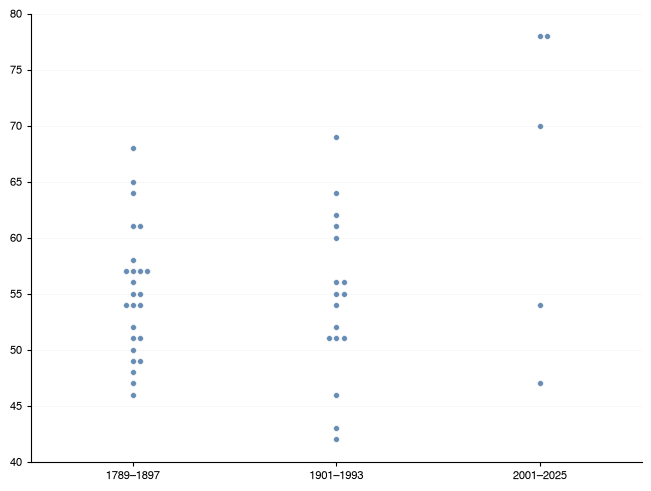

In [4]:
SwarmPlot(
    # add the data to the chart
    data=inauguration_ages
).show()

## Customizing the Swarm Plot

Every customization is either a keyword argument of `SwarmPlot` or a `plot_swarm_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                                 | See |
| :------------------------------------------ | :------------------------------------------------------------------ | :-- |
| add a title and axis labels                 | `title`, `xlabel`, `ylabel`                                         | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| fix the axis range or the ticks             | `ymin`, `ymax`, `yticks`, `xtickrotate`                             | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| resize the figure                           | `figsize`                                                           | [Figure size and grid](#figure-size-and-grid) |
| show grid lines                             | `show_grid`                                                         | [Figure size and grid](#figure-size-and-grid) |
| change the point color, size, marker, or edge | `style={"plot_swarm_color": ..., "plot_swarm_size": ...}`       | [Point style](#point-style) |
| jitter the points instead of packing them   | `mode`, `jitter`                                                    | [Swarm and strip modes](#swarm-and-strip-modes) |
| draw the swarms horizontally                | `orientation`                                                       | [Horizontal swarms](#horizontal-swarms) |
| change the order of the groups              | the order of `data`                                                 | [Horizontal swarms](#horizontal-swarms) |
| print each group's min, median, and max     | `show_values`, `value_format`                                       | [Value labels](#value-labels) |
| highlight some groups, mute the rest        | `emphasis`, `emphasis_rule`                                         | [Emphasis](#emphasis) |
| highlight single points                     | a series of their own, `emphasis`                                   | [Emphasis](#emphasis) |
| mark a threshold or shade a range           | `hlines`, `dlines`, `vlines`, `hspans`, `vspans`                  | [Reference lines and bands](#reference-lines-and-bands) |
| compare two groups with a bracket           | `brackets`                                                        | [Brackets](#brackets) |
| name a point on the chart                   | `texts`                                                             | [Text annotations](#text-annotations) |
| use dates as group labels                   | `date` objects as `label`, `xticks_format`                          | [Date labels](#date-labels) |
| put the points over a box or violin plot    | `Panel`                                                             | [Swarms over boxes and violins](#swarms-over-boxes-and-violins) |
| compare several datasets in one chart       | `data` as a list of lists, `subtitle`, `show_legend`                | [Multiple Swarm Plots](#multiple-swarm-plots) |
| title and place the legend                  | `legend`                                                            | [Legend](#legend) |
| draw each dataset in its own subplot        | `subplots`, `sharex`, `sharey`, `max_cols`                          | [Subplots](#subplots) |
| use a logarithmic value axis                | `scaley`                                                            | [Logarithmic scale](#logarithmic-scale) |
| plot data with other key names              | `label`, `value`                                                    | [Custom data keys](#custom-data-keys) |
| save the chart to a file                    | `save_figure`                                                       | [Saving Figures](../../utility/saving/) guide |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `emphasis` | [`EMPHASIS`](../../../references/constants/#datachart.constants.EMPHASIS) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |
| `legend={"location": ..., "alignment": ...}` | [`LEGEND_LOCATION`](../../../references/constants/#datachart.constants.LEGEND_LOCATION), [`LEGEND_ALIGN`](../../../references/constants/#datachart.constants.LEGEND_ALIGN) |
| `show_grid` | [`SHOW_GRID`](../../../references/constants/#datachart.constants.SHOW_GRID) |
| `mode` | [`SWARM_MODE`](../../../references/constants/#datachart.constants.SWARM_MODE) |
| `value_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT) |
| `aspect_ratio` | [`ASPECT_RATIO`](../../../references/constants/#datachart.constants.ASPECT_RATIO) |
| `orientation` | [`ORIENTATION`](../../../references/constants/#datachart.constants.ORIENTATION) |
| `scaley` | [`SCALE`](../../../references/constants/#datachart.constants.SCALE) |
| `xticks_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |
| `yticks_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |

The full list of style attributes is in the [datachart.typings.SwarmStyleAttrs](../../../references/charts/swarmplot/#datachart.typings.SwarmStyleAttrs) type; the full list of parameters is in the [datachart.charts.SwarmPlot](../../../references/charts/swarmplot/#datachart.charts.SwarmPlot) reference.

### Title, axis labels and ticks

The basic chart does not say what the points measure; `title`, `xlabel` and `ylabel` do. `ymin` and `ymax` fix the value range, and `yticks` picks the tick positions: a round range from 40 to 80 frames every age, and a tick every five years makes the ages easy to read off. Long group names can be tilted with `xtickrotate` (or `ytickrotate`); three short eras do not need it.

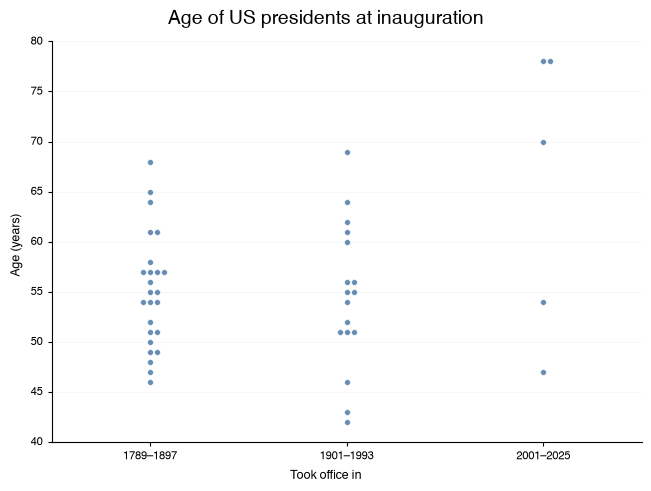

In [5]:
SwarmPlot(
    data=inauguration_ages,
    # add the title
    title="Age of US presidents at inauguration",
    # add the x and y axis labels
    xlabel="Took office in",
    ylabel="Age (years)",
    # fix the value range and the ticks
    ymin=40,
    ymax=80,
    yticks=[40, 45, 50, 55, 60, 65, 70, 75, 80],
).show()

### Figure size and grid

Three swarms do not need a square figure; a wide, short one fits a page better. `figsize` takes a `(width, height)` tuple in inches or one of the presets in [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE). Grid lines let the eye carry a point across to the value axis: `show_grid` takes a [SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID) member, and `SHOW_GRID.Y` draws them along the value axis only. `aspect_ratio` fixes the ratio of the axes ([ASPECT_RATIO](../../../references/constants/#datachart.constants.ASPECT_RATIO)); a swarm has no reason to, so the examples leave it at the default.

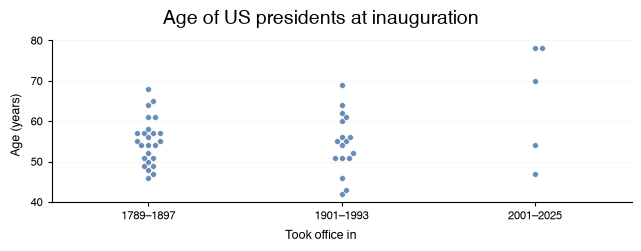

In [6]:
from datachart.constants import FIG_SIZE, SHOW_GRID

SwarmPlot(
    data=inauguration_ages,
    title="Age of US presidents at inauguration",
    xlabel="Took office in",
    ylabel="Age (years)",
    ymin=40,
    ymax=80,
    # a wide, short figure
    figsize=FIG_SIZE.FULL_SHORT,
    # grid lines along the value axis only
    show_grid=SHOW_GRID.Y,
).show()

### Point style

The `style` dictionary sets the look of the points: color, alpha, size, marker, edge and z-order; the attributes are listed in [datachart.typings.SwarmStyleAttrs](../../../references/charts/swarmplot/#datachart.typings.SwarmStyleAttrs), and any attribute left out keeps the value of the active theme. With few points, larger markers make each one count, and a white edge keeps neighbors apart where the swarm packs them tightly. The swarm packs from the marker size, so larger points spread wider. The marker shapes are listed in [LINE_MARKER](../../../references/constants/#datachart.constants.LINE_MARKER).

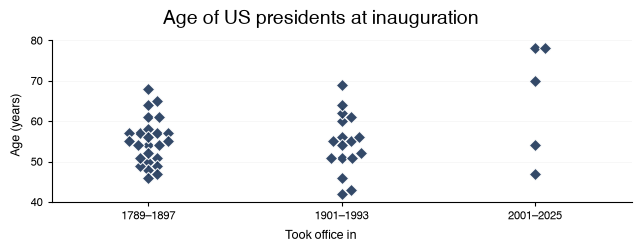

In [7]:
from datachart.constants import LINE_MARKER

SwarmPlot(
    data=inauguration_ages,
    # large diamonds with a white edge
    style={
        "plot_swarm_color": "#1d3557",
        "plot_swarm_size": 40,
        "plot_swarm_alpha": 0.9,
        "plot_swarm_marker": LINE_MARKER.DIAMOND,
        "plot_swarm_edge_color": "#ffffff",
        "plot_swarm_edge_width": 0.8,
    },
    title="Age of US presidents at inauguration",
    xlabel="Took office in",
    ylabel="Age (years)",
    ymin=40,
    ymax=80,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Swarm and strip modes

A swarm computes a place for every point so none overlap, which is what makes single points readable. With thousands of points that placement adds nothing: the swarm fills its whole width anyway, and grows wider than the category. `mode` picks the placement from [SWARM_MODE](../../../references/constants/#datachart.constants.SWARM_MODE): `SWARM_MODE.SWARM` packs the points from the marker size at the moment the chart is drawn (the default; axis limits changed on the figure afterwards can shift the spacing), and `SWARM_MODE.STRIP` scatters them at random across the category, a *strip plot*. `jitter` sets the width of the strip as a fraction of the category width (0.4 by default), and the jitter is seeded, so the same data draws the same chart. On the presidents the strip lets points overlap, so the swarm is the better choice for a sample this small; the strip earns its place in [Example 1](#example-1-which-services-breach-the-sla-strip-mode-log-scale-and-an-sla-line), with 1,200 points.

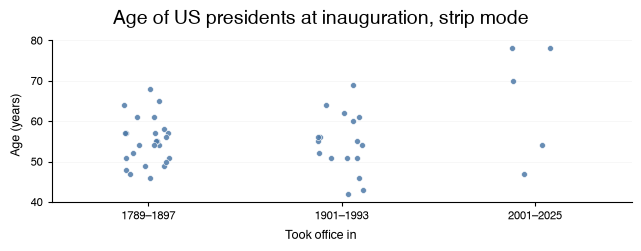

In [8]:
from datachart.constants import SWARM_MODE

SwarmPlot(
    data=inauguration_ages,
    # scatter the points at random instead of packing them
    mode=SWARM_MODE.STRIP,
    # a strip a quarter of the category wide
    jitter=0.25,
    title="Age of US presidents at inauguration, strip mode",
    xlabel="Took office in",
    ylabel="Age (years)",
    ymin=40,
    ymax=80,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Horizontal swarms

Long group names read best unrotated, and many groups read best top to bottom. `orientation=ORIENTATION.HORIZONTAL` ([ORIENTATION](../../../references/constants/#datachart.constants.ORIENTATION)) puts the groups on the y-axis and the values on the x-axis, so the axis labels, the value range and the grid swap with it. The groups follow the order in which their labels first appear in `data`, and the first group is drawn at the bottom; `SwarmPlot` has no sorting parameter, so the order is set by ordering the data. Reversing it puts the first era on top, and the eras read as a timeline from top to bottom.

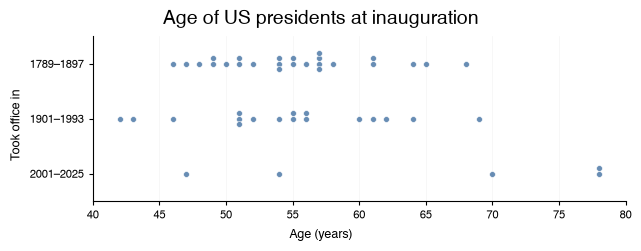

In [9]:
from datachart.constants import ORIENTATION

SwarmPlot(
    # reversed, so the first era ends up at the top
    data=inauguration_ages[::-1],
    title="Age of US presidents at inauguration",
    # the axis labels, the range and the grid swap with the orientation
    xlabel="Age (years)",
    ylabel="Took office in",
    xmin=40,
    xmax=80,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.X,
    # draw the swarms horizontally
    orientation=ORIENTATION.HORIZONTAL,
).show()

### Value labels

A reader who wants the numbers behind a swarm usually asks three things: the youngest, the oldest, and the typical age. `show_values` prints each group's minimum, median and maximum beside the points that hold them (the median beside the point nearest it), and `value_format` formats the labels: a [VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) constant or any `"{x:.1f}"`, `"{:.1f}%"` or `"%g"` style string. The label font size, color and padding are the `plot_value_*` style attributes ([ValueLabelStyleAttrs](../../../references/typings/#datachart.typings.ValueLabelStyleAttrs)). The median age barely moves across the eras; the range is what grows.

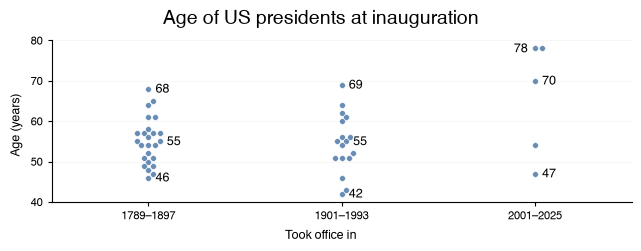

In [10]:
from datachart.constants import VALUE_FORMAT

SwarmPlot(
    data=inauguration_ages,
    style={"plot_value_fontsize": 9},
    title="Age of US presidents at inauguration",
    xlabel="Took office in",
    ylabel="Age (years)",
    ymin=40,
    ymax=80,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    # print the min, median and max of every era
    show_values=True,
    value_format=VALUE_FORMAT.INTEGER,
).show()

### Emphasis

A chart usually makes one point, and emphasis makes it visible. `emphasis` takes one role per group, aligned with the group labels in the order they first appear: `"highlight"` bolds the edges of a group's points, `"background"` mutes them into the theme's muted color, and `None` leaves them as they are; a single value applies to every group. The roles are also available as the [EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) constants, and the [Highlighting](../../styling/highlighting/) guide covers emphasis across every chart type and theme. Highlighting the last era and muting the others asks the question of the chart: are recent presidents older?

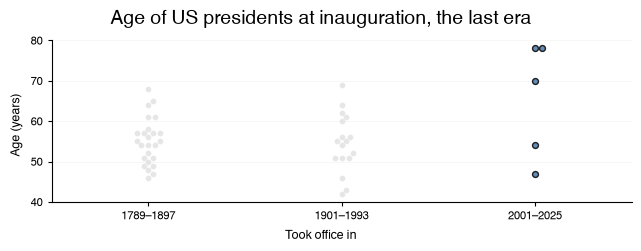

In [11]:
from datachart.constants import EMPHASIS

SwarmPlot(
    data=inauguration_ages,
    # one role per era, in the order the eras appear
    emphasis=[EMPHASIS.BACKGROUND, EMPHASIS.BACKGROUND, EMPHASIS.HIGHLIGHT],
    title="Age of US presidents at inauguration, the last era",
    xlabel="Took office in",
    ylabel="Age (years)",
    ymin=40,
    ymax=80,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

`emphasis_rule` picks the groups from the data instead of naming them. It is a dictionary with one condition, `{"top": n}` or `{"bottom": n}` by rank, `{"above": v}` or `{"below": v}` (strict), or `{"between": (lo, hi)}` (inclusive), read against a summary of each group: the median by default, or the `"mean"`, `"min"`, `"max"` or `"sum"` named by a `"by"` key. The groups that match are highlighted, the rest muted, and an explicit `emphasis` role wins over the rule. Asking which era swore in a president older than 70 highlights the last one, through its maximum:

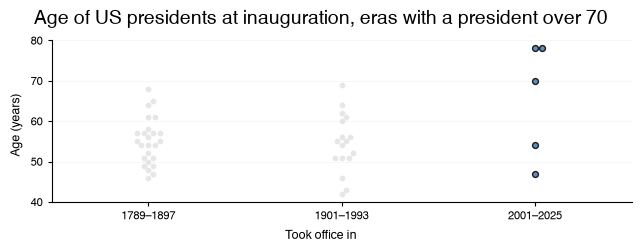

In [12]:
SwarmPlot(
    data=inauguration_ages,
    # the eras whose oldest president was over 70
    emphasis_rule={"above": 70, "by": "max"},
    title="Age of US presidents at inauguration, eras with a president over 70",
    xlabel="Took office in",
    ylabel="Age (years)",
    ymin=40,
    ymax=80,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

Emphasis works on whole groups, and a data point has no emphasis of its own. To single out a few points, move them into a series of their own (the [Multiple Swarm Plots](#multiple-swarm-plots) section covers the list-of-lists form) and give each series a role: the rest in the background, the chosen points highlighted. The two series are packed separately, so this suits points that stand apart from their group, like the two presidents who took office at 78:

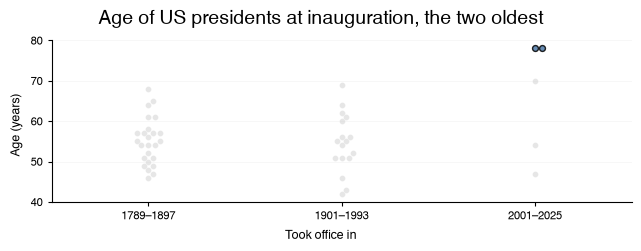

In [13]:
# the two oldest presidents in a series of their own
oldest = [point for point in inauguration_ages if point["value"] >= 78]
others = [point for point in inauguration_ages if point["value"] < 78]

SwarmPlot(
    data=[others, oldest],
    # one role per series: mute the others, highlight the oldest
    emphasis=[EMPHASIS.BACKGROUND, EMPHASIS.HIGHLIGHT],
    title="Age of US presidents at inauguration, the two oldest",
    xlabel="Took office in",
    ylabel="Age (years)",
    ymin=40,
    ymax=80,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Reference lines and bands

Reference lines and bands put the points in context. `hlines` draws a horizontal line at a value, such as a limit or the overall median, and `vlines` a vertical one; `hspans` and `vspans` shade a range instead. The groups sit at positions `1`, `2`, `3`, … along the category axis, so a vertical line at `1.5` falls between the first two groups. Each takes a dictionary or a list of them, with the position, an optional `label` for the legend and a `style`; the keys are listed in [HLineSettingAttrs](../../../references/typings/#datachart.typings.HLineSettingAttrs), [VLineSettingAttrs](../../../references/typings/#datachart.typings.VLineSettingAttrs), [HSpanSettingAttrs](../../../references/typings/#datachart.typings.HSpanSettingAttrs) and [VSpanSettingAttrs](../../../references/typings/#datachart.typings.VSpanSettingAttrs), and the line styles in [LINE_STYLE](../../../references/constants/#datachart.constants.LINE_STYLE). The US Constitution requires a president to be at least 35: a band shades the ages below it, and a dashed line marks the median age of all 47 presidencies. Nobody came close to the limit.

`dlines` completes the trio. Where `vlines` fixes an x and `hlines` a y, a diagonal is fixed by a `slope` and an `intercept`, so it runs through the data space instead of across it; `dlines={}` on its own draws the parity line `y = x`. It spans the axes unless `xmin` and `xmax` clip it to a segment, and takes the same optional `label` and `style`; the keys are listed in [DLineSettingAttrs](../../../references/typings/#datachart.typings.DLineSettingAttrs). The groups sit at `0`, `1`, `2`, … along the category axis, so a diagonal asks whether the ages drift across them: the line runs from the first group's median to the last, and the swarms standing above it took office older than that drift would have them.

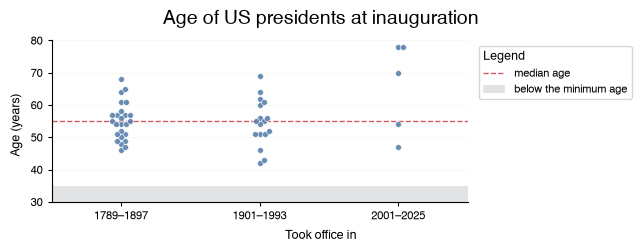

In [14]:
from statistics import median

from datachart.constants import LEGEND_LOCATION, LINE_STYLE

SwarmPlot(
    data=inauguration_ages,
    # a dashed line at the median age of all presidencies
    hlines={
        "y": median(point["value"] for point in inauguration_ages),
        "label": "median age",
        "style": {"plot_hline_color": "#c1121f", "plot_hline_style": LINE_STYLE.DASHED},
    },
    # shade the ages below the constitutional minimum
    hspans={
        "ymax": 35,
        "label": "below the minimum age",
        "style": {"plot_hspan_color": "#6c757d", "plot_hspan_alpha": 0.2},
    },
    title="Age of US presidents at inauguration",
    xlabel="Took office in",
    ylabel="Age (years)",
    ymin=30,
    ymax=80,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
    # outside the axes, clear of the points
    legend={"location": LEGEND_LOCATION.OUTSIDE_RIGHT},
).show()

In [ ]:
from statistics import median

periods = list(dict.fromkeys(point["label"] for point in inauguration_ages))
medians = [
    median(point["value"] for point in inauguration_ages if point["label"] == name)
    for name in periods
]
# the even drift from the first group to the last, in years per group
drift = (medians[-1] - medians[0]) / (len(periods) - 1)

SwarmPlot(
    data=inauguration_ages,
    # the line the medians would sit on if the age drifted evenly
    dlines={
        "slope": drift,
        "intercept": medians[0],
        "label": "even drift",
        "style": {"plot_dline_color": "#1d3557", "plot_dline_style": LINE_STYLE.DASHED},
    },
    title="Age of US presidents at inauguration against an even drift",
    xlabel="Took office in",
    ylabel="Age (years)",
    ymin=30,
    ymax=80,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
    legend={"location": LEGEND_LOCATION.OUTSIDE_RIGHT},
).show()

### Brackets

A reference line marks a value; a bracket marks a comparison. `brackets` draws a line spanning two groups, with a tick at each end pointing at them and a text above it — the conventional way to write “these two differ” on a figure. Each bracket names its ends by their labels, so no group positions are computed, and `text` is whatever you worked out elsewhere: datachart draws the result and runs no test of its own. A bracket without a `y` places itself above the data inside its span, and any two that overlap stack a step apart, so several comparisons need no hand-picked heights; the value axis grows to fit them unless the chart sets its own limit. `y` pins a bracket where the figure needs it, and `style` takes the `plot_bracket_*` attributes: the colour (which the text takes too), the line width, the alpha, and `plot_bracket_tick`, the length of the end ticks in points. On a horizontal chart the bracket spans vertically, its ticks point left and its text sits to the right. The keys are listed in [BracketSettingAttrs](../../../references/typings/#datachart.typings.BracketSettingAttrs).

The eras look different at a glance, and a bracket per pair says they are not: no comparison of inauguration ages comes near the usual 0.05 threshold. Neither bracket carries a position — the chart placed them above the swarms they span and grew the axis to fit.


In [ ]:
from scipy.stats import mannwhitneyu


def ages_of(era_name):
    return [point["value"] for point in inauguration_ages if point["label"] == era_name]


def p_text(first, second):
    """The two-sided Mann-Whitney U result, as the bracket prints it."""
    return f"p = {mannwhitneyu(ages_of(first), ages_of(second)).pvalue:.2f}"


SwarmPlot(
    data=inauguration_ages,
    brackets=[
        {"from": ERAS[0], "to": ERAS[1], "text": p_text(ERAS[0], ERAS[1])},
        {"from": ERAS[1], "to": ERAS[2], "text": p_text(ERAS[1], ERAS[2])},
    ],
    title="Age of US presidents at inauguration, era against era",
    xlabel="Took office in",
    ylabel="Age (years)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Text annotations

When the story is a single point, a note says whose it is. `texts` places text on the chart, with an optional `target` that draws a connector to a point; the position is in data coordinates by default (group position, value), or in axes fractions with `"coords": "axes"`, which keeps the note in place whatever the axis limits. The target is a group position and a value, so the connector lands on a point that sits on its group's center line, as a lone extreme usually does. The keys are listed in [TextSettingAttrs](../../../references/typings/#datachart.typings.TextSettingAttrs), and the [Text Annotations](../../utility/annotations/) guide covers placement, connectors and styling.

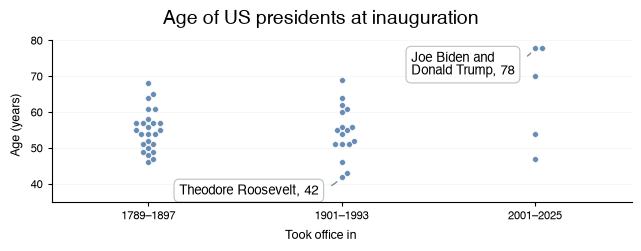

In [15]:
SwarmPlot(
    data=inauguration_ages,
    # name the youngest and the oldest presidents
    texts=[
        {
            "text": "Theodore Roosevelt, 42",
            "x": 0.22,
            "y": 0.07,
            "coords": "axes",
            "target": (1, 42),
        },
        {
            "text": "Joe Biden and\nDonald Trump, 78",
            "x": 0.62,
            "y": 0.85,
            "coords": "axes",
            "target": (2, 78),
        },
    ],
    title="Age of US presidents at inauguration",
    xlabel="Took office in",
    ylabel="Age (years)",
    # room below the youngest for the note
    ymin=35,
    ymax=80,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Date labels

Groups are often dates: race days, releases, sampling rounds. A `label` that is a real temporal object (`datetime`, `date`, `numpy.datetime64` or a pandas `Timestamp`) keeps its group position but prints through `xticks_format` (or `yticks_format` for horizontal swarms), a [DATE_FORMAT](../../../references/constants/#datachart.constants.DATE_FORMAT) member or any `strftime` pattern. `race_times`, defined in a hidden cell, holds the illustrative finishing times (in minutes) of a weekly 5 km community run on six Saturdays, labeled by the date of each run; the day and month are enough to tell the runs apart.

In [16]:
import numpy as np

# illustrative 5 km finishing times in minutes on six Saturdays
rng = np.random.RandomState(42)
RUN_DAYS = [date(2024, 9, 7), date(2024, 9, 14), date(2024, 9, 21), date(2024, 9, 28), date(2024, 10, 5), date(2024, 10, 12)]
FINISHERS = [24, 31, 18, 27, 35, 22]

race_times = [
    {"label": day, "value": round(float(np.clip(rng.lognormal(3.3, 0.18), 17, 45)), 1)}
    for day, finishers in zip(RUN_DAYS, FINISHERS)
    for _ in range(finishers)
]

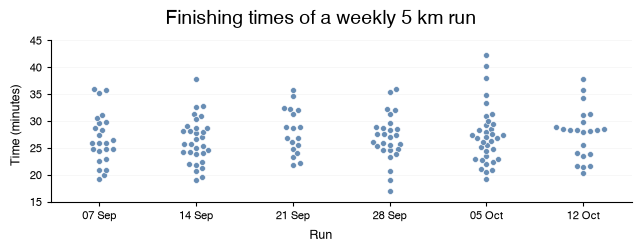

In [17]:
SwarmPlot(
    data=race_times,
    title="Finishing times of a weekly 5 km run",
    xlabel="Run",
    ylabel="Time (minutes)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    # print the date labels as day and month
    xticks_format="%d %b",
).show()

### Swarms over boxes and violins

A swarm shows every observation but leaves the reader to estimate the median and the spread; a box plot draws them but hides the observations. [Panel](../../../references/utils/#datachart.utils.Panel) overlays the two: a [BoxPlot](../../../references/charts/boxplot/#datachart.charts.BoxPlot) and a `SwarmPlot` of the same data share their group positions, so the points sit on the boxes, and the points draw above them. The box plot's outliers are already in the swarm, so `show_outliers=False` hides them, and muting the box figure with the per-figure `"emphasis"` option lets the points carry the color. The [Panel](../../utility/panel/) guide covers the per-figure options.

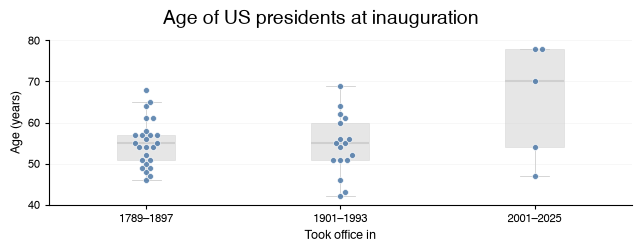

In [18]:
from datachart.charts import BoxPlot, ViolinPlot
from datachart.utils import Panel

Panel(
    [
        # the boxes in the background; the swarm already draws the outliers
        {"figure": BoxPlot(data=inauguration_ages, show_outliers=False), "emphasis": EMPHASIS.BACKGROUND},
        SwarmPlot(data=inauguration_ages),
    ],
    title="Age of US presidents at inauguration",
    xlabel="Took office in",
    ylabel_left="Age (years)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

A [ViolinPlot](../../../references/charts/violinplot/#datachart.charts.ViolinPlot) outlines the shape of each distribution instead. `inner=None` draws the body only, since the swarm already shows where the values sit, and a low alpha keeps the points legible. With five points in the last era the outline is a guess, which is exactly what the points on top reveal.

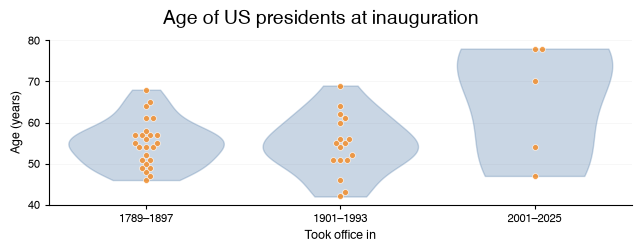

In [19]:
Panel(
    [
        # the body only, faded behind the points
        ViolinPlot(data=inauguration_ages, inner=None, style={"plot_violin_alpha": 0.3}),
        SwarmPlot(data=inauguration_ages),
    ],
    title="Age of US presidents at inauguration",
    xlabel="Took office in",
    ylabel_left="Age (years)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

## Multiple Swarm Plots

To compare datasets over the same groups, pass a list of lists to `data`: each inner list is one series, and the per-series attributes (`subtitle`, `style`, `emphasis`) become lists aligned with it. The series share one category axis, and the swarms of the same group overlay at the same position in distinct colors; `show_legend` names them by their subtitles. `ages_by_party`, defined in a hidden cell, splits the presidencies into the 16 Democratic and the 20 Republican ones (the 11 presidencies of other parties, all in the first era, are left out), and a style per series colors each party in its customary color. The two series are packed separately, so a Democrat and a Republican of the same age land on the same spot; large, translucent points for one series and small, solid points for the other keep both visible.

In [20]:
PARTIES = ["Democratic", "Republican"]
PARTY_COLORS = ["#1f4e9c", "#c1121f"]

ages_by_party = [
    [
        {"label": era(took), "value": age_on(born, took)}
        for _, p, born, took, _ in PRESIDENCIES
        if p == party
    ]
    for party in PARTIES
]

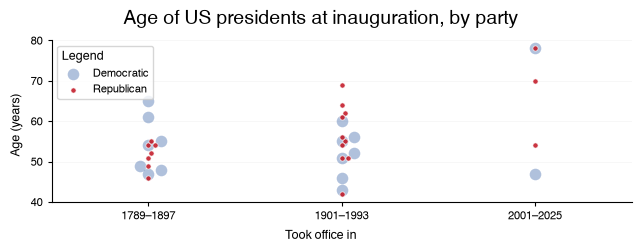

In [21]:
# large, translucent Democrats under small, solid Republicans
PARTY_STYLE = [
    {"plot_swarm_color": PARTY_COLORS[0], "plot_swarm_size": 70, "plot_swarm_alpha": 0.35, "plot_swarm_edge_width": 0},
    {"plot_swarm_color": PARTY_COLORS[1], "plot_swarm_size": 14},
]

SwarmPlot(
    # one series per party
    data=ages_by_party,
    # named for the legend
    subtitle=PARTIES,
    # and colored like the party
    style=PARTY_STYLE,
    title="Age of US presidents at inauguration, by party",
    xlabel="Took office in",
    ylabel="Age (years)",
    ymin=40,
    ymax=80,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Legend

`show_legend` lists the series; `legend` says where and how, with a `title`, a `location` from [LEGEND_LOCATION](../../../references/constants/#datachart.constants.LEGEND_LOCATION), the number of columns `ncols`, and the `alignment` of the entries from [LEGEND_ALIGN](../../../references/constants/#datachart.constants.LEGEND_ALIGN); a field left out falls back to the theme ([LegendSettingAttrs](../../../references/typings/#datachart.typings.LegendSettingAttrs)). The swarms reach the top corners of the chart, so the legend moves above the axes, titled and with both entries in one row.

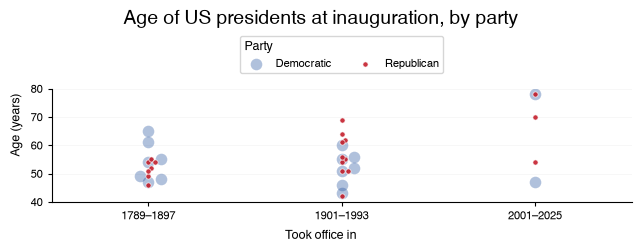

In [22]:
SwarmPlot(
    data=ages_by_party,
    subtitle=PARTIES,
    style=PARTY_STYLE,
    title="Age of US presidents at inauguration, by party",
    xlabel="Took office in",
    ylabel="Age (years)",
    ymin=40,
    ymax=80,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
    # a titled legend above the axes, in one row
    legend={"title": "Party", "location": LEGEND_LOCATION.OUTSIDE_TOP, "ncols": 2},
).show()

### Subplots

Overlaid swarms pack separately, so two series at the same group can cover each other, and the size trick above only goes so far. `subplots=True` draws each series in its own panel instead: `subtitle` titles the panels, `title`, `xlabel` and `ylabel` stay global, and `max_cols` limits the panels per row. `sharey=True` puts the panels on one value axis, so an age in one panel compares with an age in the next, and `sharex=True` keeps one category axis for both.

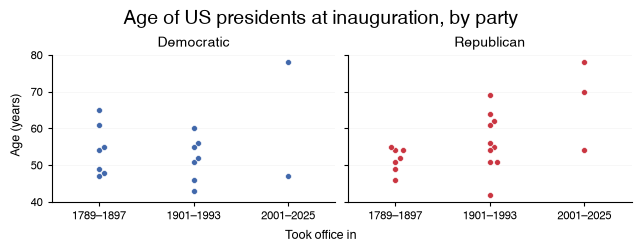

In [23]:
SwarmPlot(
    data=ages_by_party,
    subtitle=PARTIES,
    # one color per party, the same point size in both panels
    style=[{"plot_swarm_color": color} for color in PARTY_COLORS],
    title="Age of US presidents at inauguration, by party",
    xlabel="Took office in",
    ylabel="Age (years)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    # one panel per party, side by side
    subplots=True,
    # one value axis and one category axis for both panels
    sharex=True,
    sharey=True,
).show()

## Additional Features

### Logarithmic scale

Some values span orders of magnitude, and on a linear axis the small ones pile up at the bottom. `scaley` takes a [SCALE](../../../references/constants/#datachart.constants.SCALE) member, and the swarm packs the points on the scaled axis, so they stay apart. `days_in_office`, defined in a hidden cell, holds the length of each completed presidency in days, from William Henry Harrison's 31 days to Franklin D. Roosevelt's 4,422 (the current presidency is left out). The log axis spreads the short presidencies, cut short by death or resignation, as clearly as the long ones, and the value labels name the extremes of each era.

In [24]:
days_in_office = [
    {"label": era(took), "value": (left - took).days}
    for _, _, _, took, left in PRESIDENCIES
    if left is not None
]

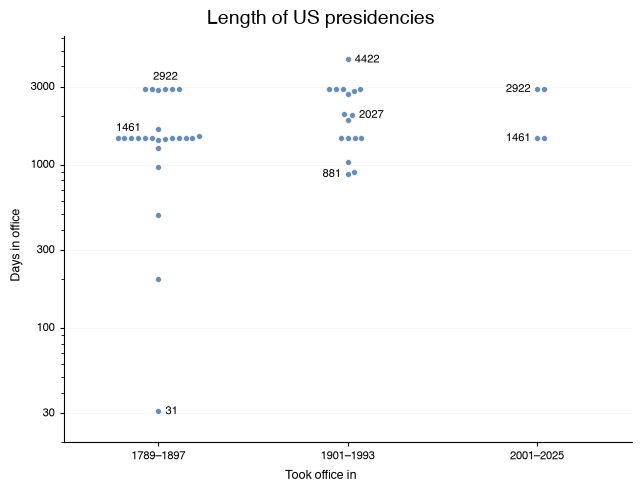

In [25]:
from datachart.constants import SCALE

SwarmPlot(
    data=days_in_office,
    title="Length of US presidencies",
    xlabel="Took office in",
    ylabel="Days in office",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.Y,
    show_values=True,
    # draw the value axis on a logarithmic scale
    scaley=SCALE.LOG,
    # ticks at readable round numbers
    yticks=[30, 100, 300, 1000, 3000],
    ymin=20,
).show()

### Custom data keys

Data that comes from a file or an API rarely uses the `label` and `value` keys, and renaming every record just to plot it is a chore. Instead, tell `SwarmPlot` which keys to read with the `label` and `value` arguments. `president_records` stores the presidencies the way a CSV export would, one record per presidency with a `name`, an `era` and an `age` key:

In [26]:
president_records = [
    {"name": name, "era": era(took), "age": age_on(born, took)}
    for name, _, born, took, _ in PRESIDENCIES
]
president_records[:2]

[{'name': 'George Washington', 'era': '1789–1897', 'age': 57},
 {'name': 'John Adams', 'era': '1789–1897', 'age': 61}]

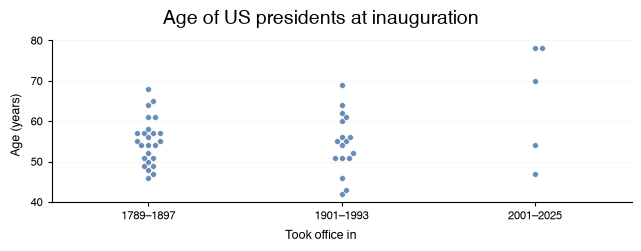

In [27]:
SwarmPlot(
    data=president_records,
    # the keys that hold the group and the value
    label="era",
    value="age",
    title="Age of US presidents at inauguration",
    xlabel="Took office in",
    ylabel="Age (years)",
    ymin=40,
    ymax=80,
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

## Real-World Examples

The examples below put the features above to work on realistic data, each one answering a question. The data lives in hidden cells; each example says what its data is and where it comes from.

### Example 1: Which Services Breach the SLA? (Strip Mode, Log Scale and an SLA Line)

`response_times` holds the illustrative response times (in ms) of 300 requests to each of four services, drawn from a seeded log-normal generator: most requests are fast, and a long tail of slow ones stretches each distribution. The question is which services break the 500 ms service level agreement (SLA), and how often. With 1,200 points a swarm would overflow its category, so the strip mode scatters them instead, with small, translucent points so the dense regions read darker. On a log axis the tail reads at the same resolution as the bulk, and a shaded band above the SLA line holds the requests that breach it.

In [28]:
rng = np.random.RandomState(5)

# log-normal parameters (mean and sigma of the log) of each service's response time
SERVICES = {
    "Auth": (4.6, 0.25),
    "Search": (5.3, 0.45),
    "Checkout": (5.0, 0.35),
    "Reports": (5.6, 0.55),
}
N_REQUESTS = 300
SLA_MS = 500

response_times = [
    {"label": service, "value": float(rng.lognormal(mean, sigma))}
    for service, (mean, sigma) in SERVICES.items()
    for _ in range(N_REQUESTS)
]

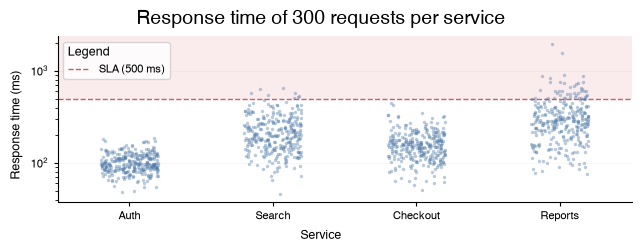

In [29]:
SwarmPlot(
    data=response_times,
    # scatter the many points across the category width
    mode=SWARM_MODE.STRIP,
    # small, translucent points
    style={"plot_swarm_size": 6, "plot_swarm_alpha": 0.4, "plot_swarm_edge_width": 0},
    # the long tail reads at the same resolution as the bulk
    scaley=SCALE.LOG,
    # the SLA, and the requests that breach it
    hlines={
        "y": SLA_MS,
        "label": f"SLA ({SLA_MS} ms)",
        "style": {"plot_hline_color": "#c1121f", "plot_hline_style": LINE_STYLE.DASHED},
    },
    hspans={
        "ymin": SLA_MS,
        "style": {"plot_hspan_color": "#c1121f", "plot_hspan_alpha": 0.08},
    },
    title=f"Response time of {N_REQUESTS} requests per service",
    xlabel="Service",
    ylabel="Response time (ms)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
    legend={"location": LEGEND_LOCATION.UPPER_LEFT},
).show()

### Example 2: Which Months Bring Frost? (Horizontal Swarms, a Rule and a Frost Band)

`daily_temperatures` holds one year of illustrative daily mean temperatures (in °C) in Ljubljana, drawn from a seeded generator around the city's published 1991–2020 monthly climate normals, with larger day-to-day swings in winter. The question is which months bring freezing days. Twelve labeled swarms read best top to bottom, so the swarms are horizontal and the data is reversed to put January on top. A band shades the temperatures below zero, so the frost days are the points inside it, and `emphasis_rule` highlights the months whose coldest day fell below freezing, through the `"min"` summary.

In [30]:
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
DAYS_IN_MONTH = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
# mean monthly temperature in °C, 1991–2020 climate normals of Ljubljana
LJUBLJANA_NORMALS = [0.8, 2.4, 6.8, 11.5, 16.2, 20.1, 22.0, 21.4, 16.6, 11.5, 5.9, 1.3]
# day-to-day spread in °C, larger in winter
DAILY_SPREAD = [3.5, 3.5, 3.0, 2.8, 2.5, 2.2, 2.0, 2.0, 2.5, 2.8, 3.0, 3.5]

rng = np.random.RandomState(11)
daily_temperatures = [
    {"label": month, "value": round(float(rng.normal(normal, spread)), 1)}
    for month, days, normal, spread in zip(MONTHS, DAYS_IN_MONTH, LJUBLJANA_NORMALS, DAILY_SPREAD)
    for _ in range(days)
]

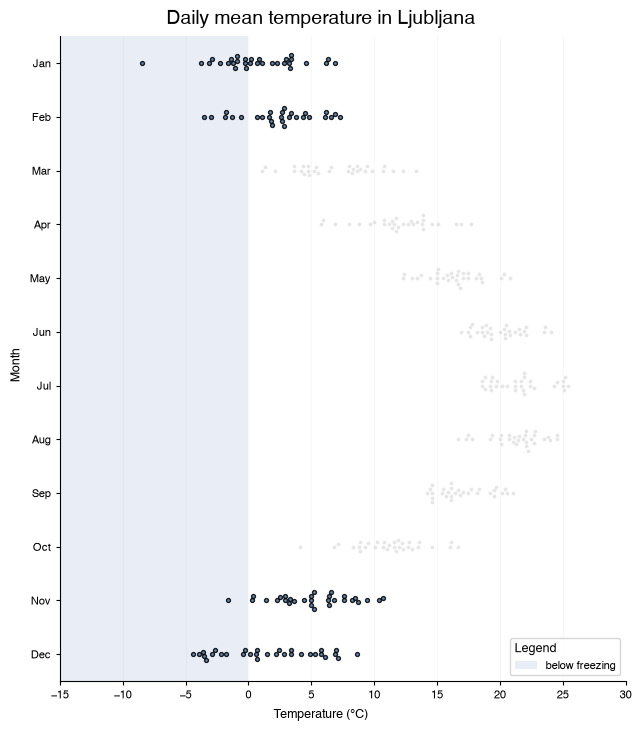

In [31]:
SwarmPlot(
    # reversed, so January ends up at the top
    data=daily_temperatures[::-1],
    orientation=ORIENTATION.HORIZONTAL,
    style={"plot_swarm_size": 8},
    # the months whose coldest day was below zero
    emphasis_rule={"below": 0, "by": "min"},
    # shade the freezing temperatures
    vspans={
        "xmax": 0,
        "label": "below freezing",
        "style": {"plot_vspan_color": "#4c72b0", "plot_vspan_alpha": 0.12},
    },
    title="Daily mean temperature in Ljubljana",
    xlabel="Temperature (°C)",
    ylabel="Month",
    figsize=FIG_SIZE.FULL_TALL,
    show_grid=SHOW_GRID.X,
    show_legend=True,
    legend={"location": LEGEND_LOCATION.LOWER_RIGHT},
).show()

### Example 3: Is the Best Model Better, or Just Luckier? (Box Overlay, Emphasis and a Note)

`benchmark` holds the illustrative test accuracy of five models, each trained with 10 random seeds, drawn from a seeded generator. Ten runs per model is a small sample, and the question is whether the model with the best single run is also the most reliable. A box plot alone hides the runs; the swarm on top shows every one, so a tight cluster reads apart from a wide one. [Panel](../../../references/utils/#datachart.utils.Panel) overlays the two, the same `emphasis` roles on both figures highlight the two leading models and mute the rest, and [Annotate](../../../references/utils/#datachart.utils.Annotate) adds a note to the finished panel, pointing at the single best run.

In [32]:
rng = np.random.RandomState(7)

# mean and standard deviation of each model's test accuracy across seeds
MODELS = {
    "Baseline": (0.812, 0.012),
    "Wide": (0.836, 0.010),
    "Deep": (0.861, 0.022),
    "Deep + aug.": (0.866, 0.006),
    "Ensemble": (0.848, 0.008),
}
N_SEEDS = 10

benchmark = [
    {"label": model, "value": round(float(rng.normal(mean, std)), 4)}
    for model, (mean, std) in MODELS.items()
    for _ in range(N_SEEDS)
]
BEST_RUN = max(benchmark, key=lambda point: point["value"])

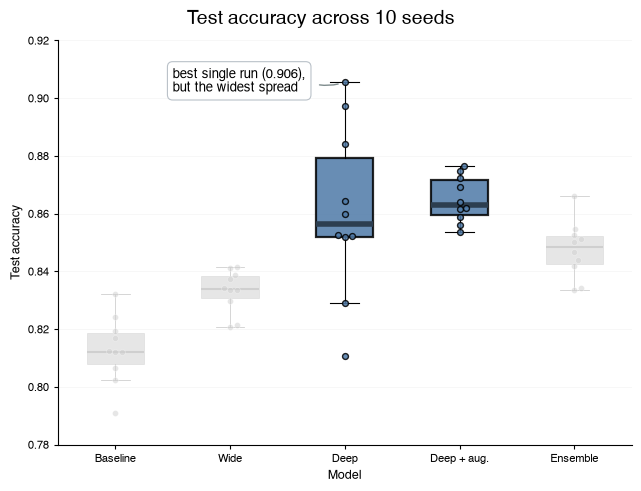

In [33]:
from datachart.utils import Annotate

LEADERS = ["Deep", "Deep + aug."]
roles = [EMPHASIS.HIGHLIGHT if model in LEADERS else EMPHASIS.BACKGROUND for model in MODELS]

panel = Panel(
    [
        BoxPlot(data=benchmark, show_outliers=False, emphasis=roles),
        # the same roles align with the same models in both figures
        SwarmPlot(data=benchmark, emphasis=roles),
    ],
    title=f"Test accuracy across {N_SEEDS} seeds",
    xlabel="Model",
    ylabel_left="Test accuracy",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.Y,
)

# point at the single best run; groups sit at positions 0, 1, 2, ...
position = list(MODELS).index(BEST_RUN["label"])
Annotate(
    panel,
    texts={
        "text": f"best single run ({BEST_RUN['value']:.3f}),\nbut the widest spread",
        "x": 0.2,
        "y": 0.9,
        "coords": "axes",
        "target": (position, BEST_RUN["value"]),
    },
).show()